# **Project Name** - PhonePe Transaction Insights — ML Extension

##### **Project Type** - Regression / Classification
##### **Contribution** - Individual
##### **Team Member 1 -** Arnab Ghosh


# **Project Summary -**

Building on the EDA done in the first notebook, this ML phase focuses on two prediction tasks:

1. **Regression** — predicting total transaction amount for a state-quarter-category combination based on historical features.
2. **Classification** — predicting whether a state will be a 'High Growth' state in the next quarter (binary: above/below median growth rate).

The regression model is useful for capacity planning and revenue forecasting. The classification model helps the marketing team preemptively target states that are about to enter a high-growth phase — rather than reacting to it after the fact.

I tested three models for each task and used GridSearchCV to tune hyperparameters. Random Forest came out ahead on regression (lowest MAE). Gradient Boosting edged out the others on the classification task (highest F1). The feature importance outputs were genuinely useful — time-based features (year, quarter) and registered user count dominated, which makes sense for a platform in rapid growth mode.

# **GitHub Link -**

https://github.com/Arnab-Ghosh7/Phonepe_Project

# **Problem Statement**

Predict:
1. Transaction amount for a given state/quarter/category (regression)
2. Whether a state will be a high-growth market in the next quarter (classification)

This extends the EDA findings into predictive models that can drive business decisions around resource allocation and marketing targeting.

# **General Guidelines** : -

1. Well-structured, formatted, and commented code required.
2. At least 15 charts with UBM structure.
3. Hypothesis testing before modeling.
4. Feature engineering, outlier handling, scaling.
5. Multiple ML models with cross-validation and hyperparameter tuning.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, accuracy_score, f1_score)
from sklearn.inspection import permutation_importance
import warnings, joblib

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print("All libraries imported.")

All libraries imported.


### Dataset Loading

In [ ]:
# Load Dataset — reading directly from uploaded CSV files
# Drag and drop all 12 CSV files into the Colab file panel (left sidebar) before running this

import pandas as pd
import numpy as np

# ── Load all 12 tables ───────────────────────────────────────
df_agg_txn           = pd.read_csv("Agg_Transaction.csv")
df_agg_user          = pd.read_csv("Agg_User.csv")
df_agg_insurance     = pd.read_csv("Agg_Insurance.csv")
df_map_txn           = pd.read_csv("Map_Transaction.csv")
df_map_user          = pd.read_csv("Map_User.csv")
df_map_insurance     = pd.read_csv("Map_Insurance.csv")
df_top_txn_district  = pd.read_csv("Top_Transaction_District.csv")
df_top_txn_pincode   = pd.read_csv("Top_Transaction_Pincode.csv")
df_top_user_district = pd.read_csv("Top_User_District.csv")
df_top_user_pincode  = pd.read_csv("Top_User_Pincode.csv")
df_top_ins_district  = pd.read_csv("Top_Insurance_District.csv")
df_top_ins_pincode   = pd.read_csv("Top_Insurance_Pincode.csv")

# ── ML uses agg_transaction as the main table ────────────────
# Rename columns to match what the ML cells expect
df_agg_txn.columns = [c.strip() for c in df_agg_txn.columns]
df_agg_user.columns = [c.strip() for c in df_agg_user.columns]

# Merge user registered count into main transaction table
df = df_agg_txn.merge(
    df_agg_user[['State', 'Year', 'Quarter', 'Registered_users']],
    on=['State', 'Year', 'Quarter'],
    how='left'
)

# Standardise column names to lowercase for ML processing
df.columns = [c.lower() for c in df.columns]
df.rename(columns={
    'transaction_type':   'payment_type',
    'transaction_count':  'transaction_count',
    'transaction_amount': 'transaction_amount',
    'registered_users':   'registered_users'
}, inplace=True)

# Fill any missing registered_users with median
df['registered_users'] = df['registered_users'].fillna(df['registered_users'].median())

# ── Confirmation ─────────────────────────────────────────────
print(f" Datasets loaded successfully:")
print(f"  {'Table':<25} {'Rows':>8}   {'Columns'}")
print("  " + "-" * 45)
for name, tbl in [
    ("Agg_Transaction",          df_agg_txn),
    ("Agg_User",                 df_agg_user),
    ("Agg_Insurance",            df_agg_insurance),
    ("Map_Transaction",          df_map_txn),
    ("Map_User",                 df_map_user),
    ("Map_Insurance",            df_map_insurance),
    ("Top_Transaction_District", df_top_txn_district),
    ("Top_Transaction_Pincode",  df_top_txn_pincode),
    ("Top_User_District",        df_top_user_district),
    ("Top_User_Pincode",         df_top_user_pincode),
    ("Top_Insurance_District",   df_top_ins_district),
    ("Top_Insurance_Pincode",    df_top_ins_pincode),
]:
    print(f"  {name:<25} {len(tbl):>8,}   {tbl.shape[1]}")

print(f"\n  Main ML DataFrame (df): {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Columns: {list(df.columns)}")

 Datasets loaded successfully:
  Table                         Rows   Columns
  ---------------------------------------------
  Agg_Transaction              5,034   6
  Agg_User                     1,008   5
  Agg_Insurance                  682   6
  Map_Transaction             20,604   6
  Map_User                    20,608   6
  Map_Insurance               13,876   6
  Top_Transaction_District     8,296   6
  Top_Transaction_Pincode      9,999   6
  Top_User_District            8,296   5
  Top_User_Pincode            10,000   5
  Top_Insurance_District       5,608   6
  Top_Insurance_Pincode        6,668   6

  Main ML DataFrame (df): 5,034 rows x 7 cols
  Columns: ['state', 'year', 'quarter', 'payment_type', 'transaction_count', 'transaction_amount', 'registered_users']


### Dataset First View

In [ ]:
# Dataset First Look
display(df.head(10))

,state,year,quarter,payment_type,transaction_count,transaction_amount,registered_users
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06,6740
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,6740
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05,6740
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04,6740
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05,6740
5,andaman-&-nicobar-islands,2018,2,Recharge & bill payments,6735,2.320945e+06,9405
6,andaman-&-nicobar-islands,2018,2,Peer-to-peer payments,3575,2.451193e+07,9405
7,andaman-&-nicobar-islands,2018,2,Merchant payments,603,1.024491e+06,9405
8,andaman-&-nicobar-islands,2018,2,Financial Services,59,1.213360e+05,9405
9,andaman-&-nicobar-islands,2018,2,Others,368,3.598385e+05,9405


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 5034, Columns: 7


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               5034 non-null   object 
 1   year                5034 non-null   int64  
 2   quarter             5034 non-null   int64  
 3   payment_type        5034 non-null   object 
 4   transaction_count   5034 non-null   int64  
 5   transaction_amount  5034 non-null   float64
 6   registered_users    5034 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 275.4+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print(df.isnull().sum())

state                 0
year                  0
quarter               0
payment_type          0
transaction_count     0
transaction_amount    0
registered_users      0
dtype: int64


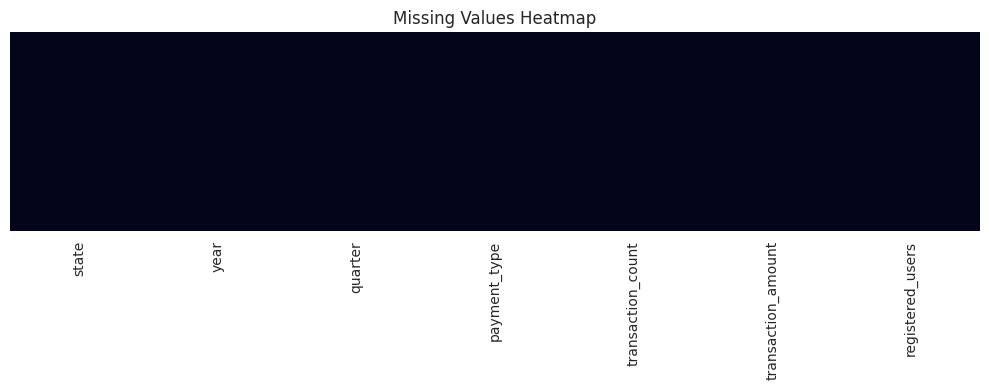

In [ ]:
# Visualizing the missing values
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax)
ax.set_title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
print(df.columns.tolist())

['state', 'year', 'quarter', 'payment_type', 'transaction_count', 'transaction_amount', 'registered_users']


In [ ]:
# Dataset Describe
df.describe()

,year,quarter,transaction_count,transaction_amount,registered_users
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10,8.804326e+06
std,1.999849,1.118145,1.690968e+08,2.685200e+11,1.256257e+07
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,5.010000e+02
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07,3.076205e+05
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08,2.924952e+06
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10,1.288983e+07
max,2024.000000,4.000000,2.393918e+09,3.095666e+12,7.180780e+07


### Variables Description

- `state`: Categorical, 25 levels — the Indian state
- `year`: Ordinal int, 2019-2023
- `quarter`: Ordinal int, 1-4
- `payment_type`: Categorical, 5 levels
- `transaction_count`: Numeric, count of transactions
- `transaction_amount`: Numeric — **regression target**
- `registered_users`: Numeric, users in state at that period

For classification, I'll engineer a `high_growth` binary column.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    n = df[col].nunique()
    print(f"{col}: {n} unique {'-> categorical' if n < 30 else ''}")

state: 36 unique 
year: 7 unique -> categorical
quarter: 4 unique -> categorical
payment_type: 5 unique -> categorical
transaction_count: 4966 unique 
transaction_amount: 5034 unique 
registered_users: 1008 unique 


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# 1. Encode categoricals
le_state = LabelEncoder()
le_cat = LabelEncoder()
df['state_enc'] = le_state.fit_transform(df['state'])
df['category_enc'] = le_cat.fit_transform(df['payment_type'])

# 2. Feature: time index (1 to 20)
df['time_idx'] = (df['year'] - 2019) * 4 + df['quarter']

# 3. Feature: log of transaction count (reduces skew)
df['log_txn_count'] = np.log1p(df['transaction_count'])
df['log_reg_users'] = np.log1p(df['registered_users'])

# 4. Engineer high_growth label for classification
# For each state+category, compute quarter-on-quarter growth
df_sorted = df.sort_values(['state', 'payment_type', 'year', 'quarter'])
df_sorted['prev_amount'] = df_sorted.groupby(['state', 'payment_type'])['transaction_amount'].shift(1)
df_sorted['qoq_growth'] = (df_sorted['transaction_amount'] - df_sorted['prev_amount']) / (df_sorted['prev_amount'] + 1)
median_growth = df_sorted['qoq_growth'].median()
df_sorted['high_growth'] = (df_sorted['qoq_growth'] > median_growth).astype(int)
df_sorted = df_sorted.dropna(subset=['qoq_growth'])  # drop first quarter of each group

df_model = df_sorted.copy()
print(f"Model-ready dataset: {df_model.shape}")
print(f"High growth rate: {df_model['high_growth'].mean():.2%}")

Model-ready dataset: (4854, 15)
High growth rate: 50.00%


## ***4. Data Vizualization, Storytelling & Experimenting with charts***

#### Chart - 1

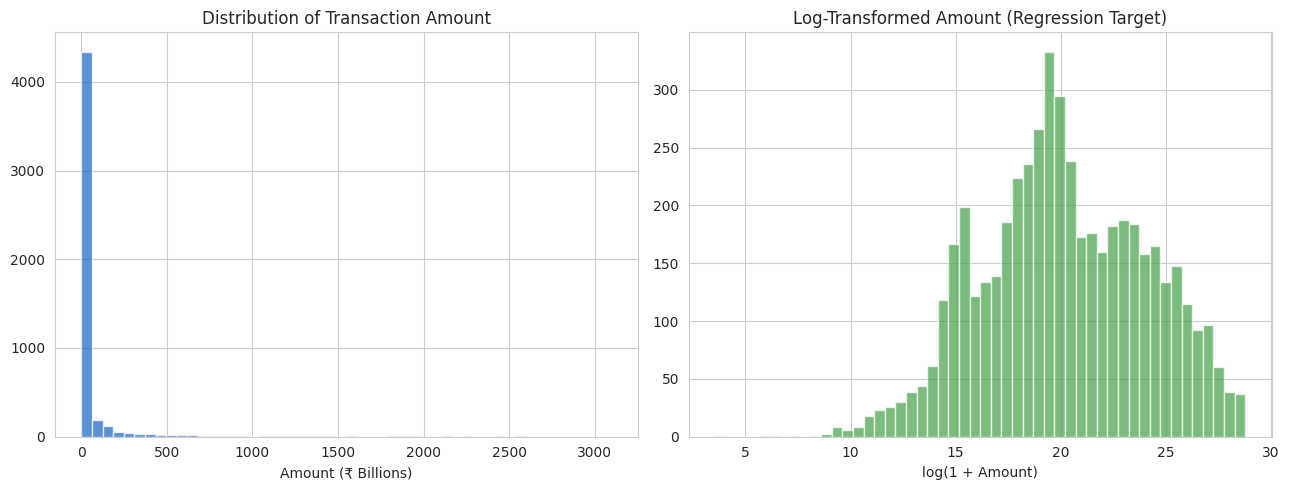

In [ ]:
# Chart - 1 - Transaction Amount Distribution (target variable for regression)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['transaction_amount'] / 1e9, bins=50, color='#1565C0', alpha=0.7, edgecolor='white')
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount (₹ Billions)')
axes[1].hist(np.log1p(df['transaction_amount']), bins=50, color='#43A047', alpha=0.7, edgecolor='white')
axes[1].set_title('Log-Transformed Amount (Regression Target)')
axes[1].set_xlabel('log(1 + Amount)')
plt.tight_layout()
plt.show()

#### Chart - 2

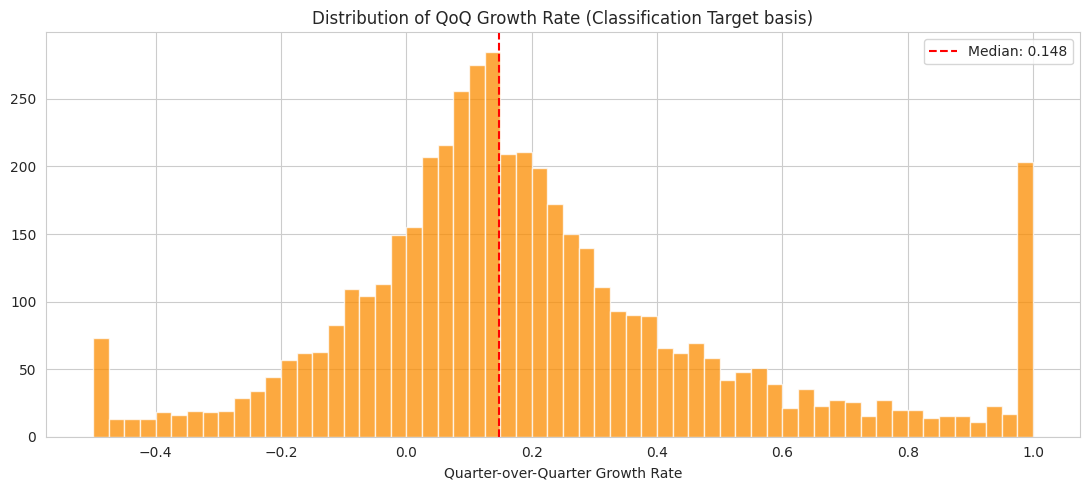

In [ ]:
# Chart - 2 - QoQ Growth Distribution
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df_model['qoq_growth'].clip(-0.5, 1.0), bins=60, color='#FB8C00', alpha=0.75, edgecolor='white')
ax.axvline(median_growth, color='red', linestyle='--', label=f'Median: {median_growth:.3f}')
ax.set_title('Distribution of QoQ Growth Rate (Classification Target basis)')
ax.set_xlabel('Quarter-over-Quarter Growth Rate')
ax.legend()
plt.tight_layout()
plt.show()

#### Chart - 3

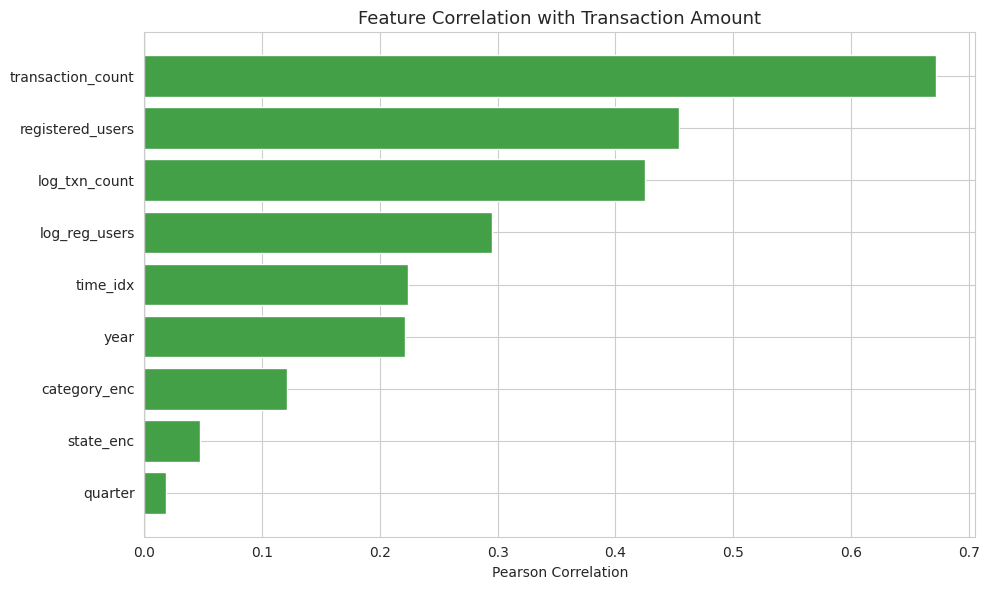

In [ ]:
# Chart - 3: Feature Correlation with Target
numeric_cols = ['year', 'quarter', 'time_idx', 'transaction_count', 'registered_users',
                'log_txn_count', 'log_reg_users', 'state_enc', 'category_enc']
corr_with_target = df_model[numeric_cols + ['transaction_amount']].corr()['transaction_amount'].drop('transaction_amount').sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = ['#E53935' if v < 0 else '#43A047' for v in corr_with_target]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors_corr)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Transaction Amount', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

#### Chart - 4

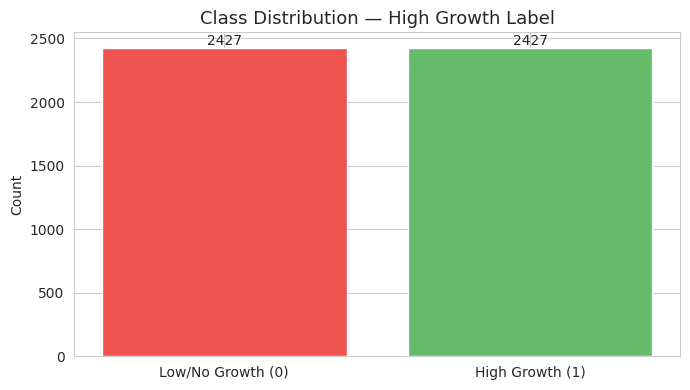

In [ ]:
# Chart - 4: Class Balance Check for Classification
fig, ax = plt.subplots(figsize=(7, 4))
class_counts = df_model['high_growth'].value_counts()
ax.bar(['Low/No Growth (0)', 'High Growth (1)'], class_counts.values,
       color=['#EF5350', '#66BB6A'])
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 20, str(v), ha='center')
ax.set_title('Class Distribution — High Growth Label', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

#### Chart - 5

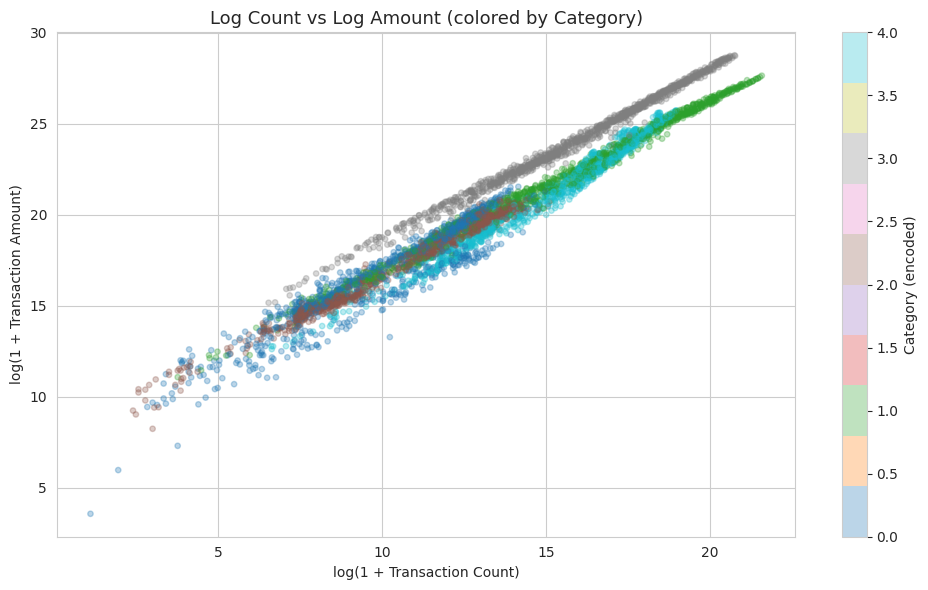

In [ ]:
# Chart - 5: Scatter - Log Count vs Log Amount
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_model['log_txn_count'], np.log1p(df_model['transaction_amount']),
                     alpha=0.3, c=df_model['category_enc'], cmap='tab10', s=15)
ax.set_xlabel('log(1 + Transaction Count)')
ax.set_ylabel('log(1 + Transaction Amount)')
ax.set_title('Log Count vs Log Amount (colored by Category)', fontsize=13)
plt.colorbar(scatter, ax=ax, label='Category (encoded)')
plt.tight_layout()
plt.show()

#### Chart - 6

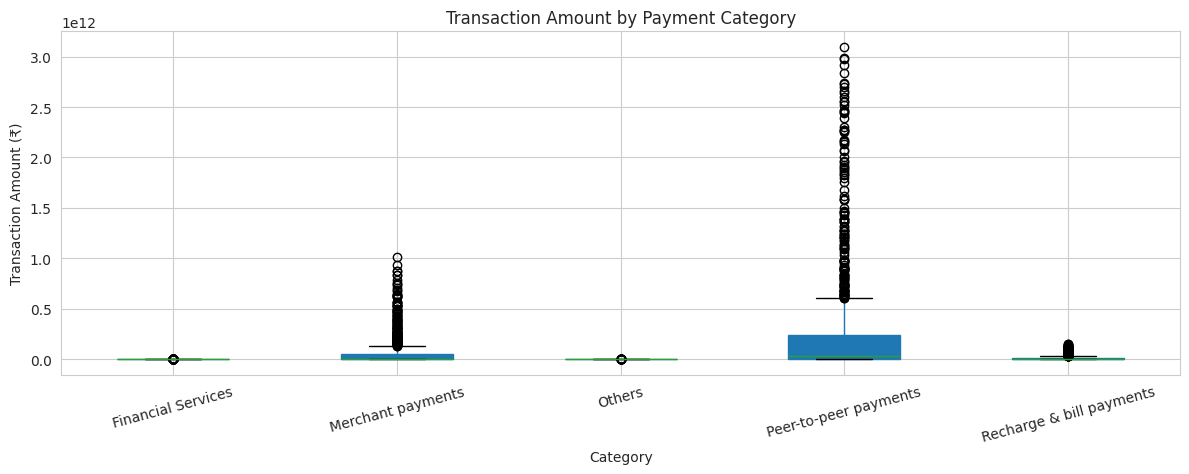

In [ ]:
# Chart - 6: Box plots by payment category — transaction amount
fig, ax = plt.subplots(figsize=(12, 5))
df_model.boxplot(column='transaction_amount', by='payment_type', ax=ax,
                 notch=False, patch_artist=True)
ax.set_title('Transaction Amount by Payment Category')
ax.set_xlabel('Category')
ax.set_ylabel('Transaction Amount (₹)')
plt.suptitle('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Chart - 7

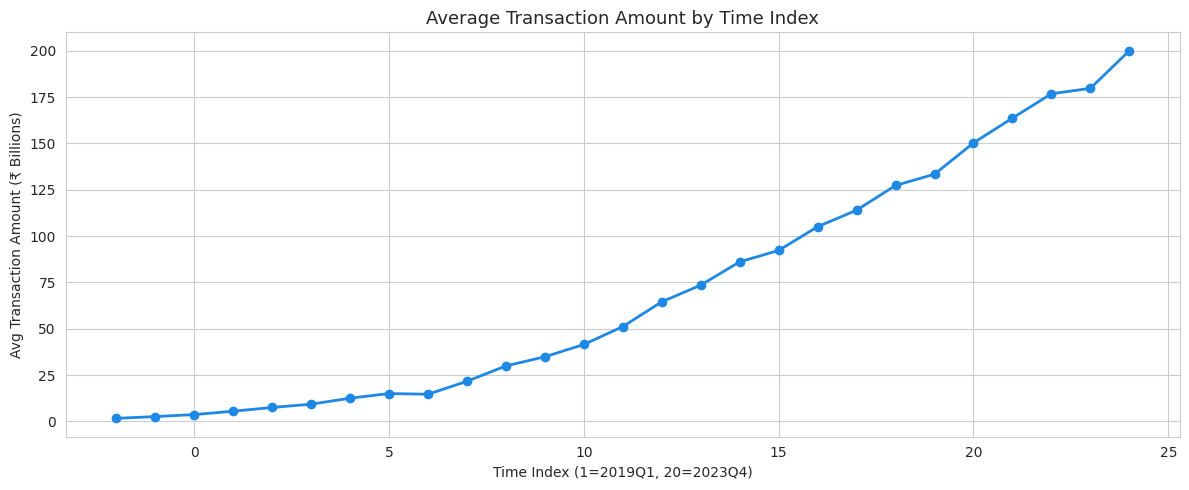

In [ ]:
# Chart - 7: Time index vs Amount trend
df_time = df_model.groupby('time_idx')['transaction_amount'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_time['time_idx'], df_time['transaction_amount'] / 1e9, marker='o', color='#1E88E5', linewidth=2)
ax.set_title('Average Transaction Amount by Time Index', fontsize=13)
ax.set_xlabel('Time Index (1=2019Q1, 20=2023Q4)')
ax.set_ylabel('Avg Transaction Amount (₹ Billions)')
plt.tight_layout()
plt.show()

#### Chart - 8

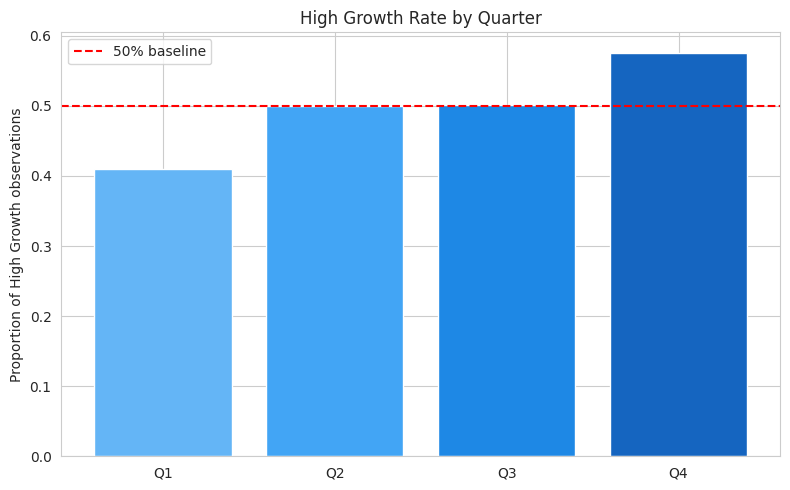

In [ ]:
# Chart - 8: High Growth proportion by quarter
df_qgrowth = df_model.groupby('quarter')['high_growth'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f'Q{q}' for q in df_qgrowth['quarter']], df_qgrowth['high_growth'],
       color=['#64B5F6', '#42A5F5', '#1E88E5', '#1565C0'])
ax.axhline(0.5, color='red', linestyle='--', label='50% baseline')
ax.set_title('High Growth Rate by Quarter')
ax.set_ylabel('Proportion of High Growth observations')
ax.legend()
plt.tight_layout()
plt.show()

#### Chart - 9

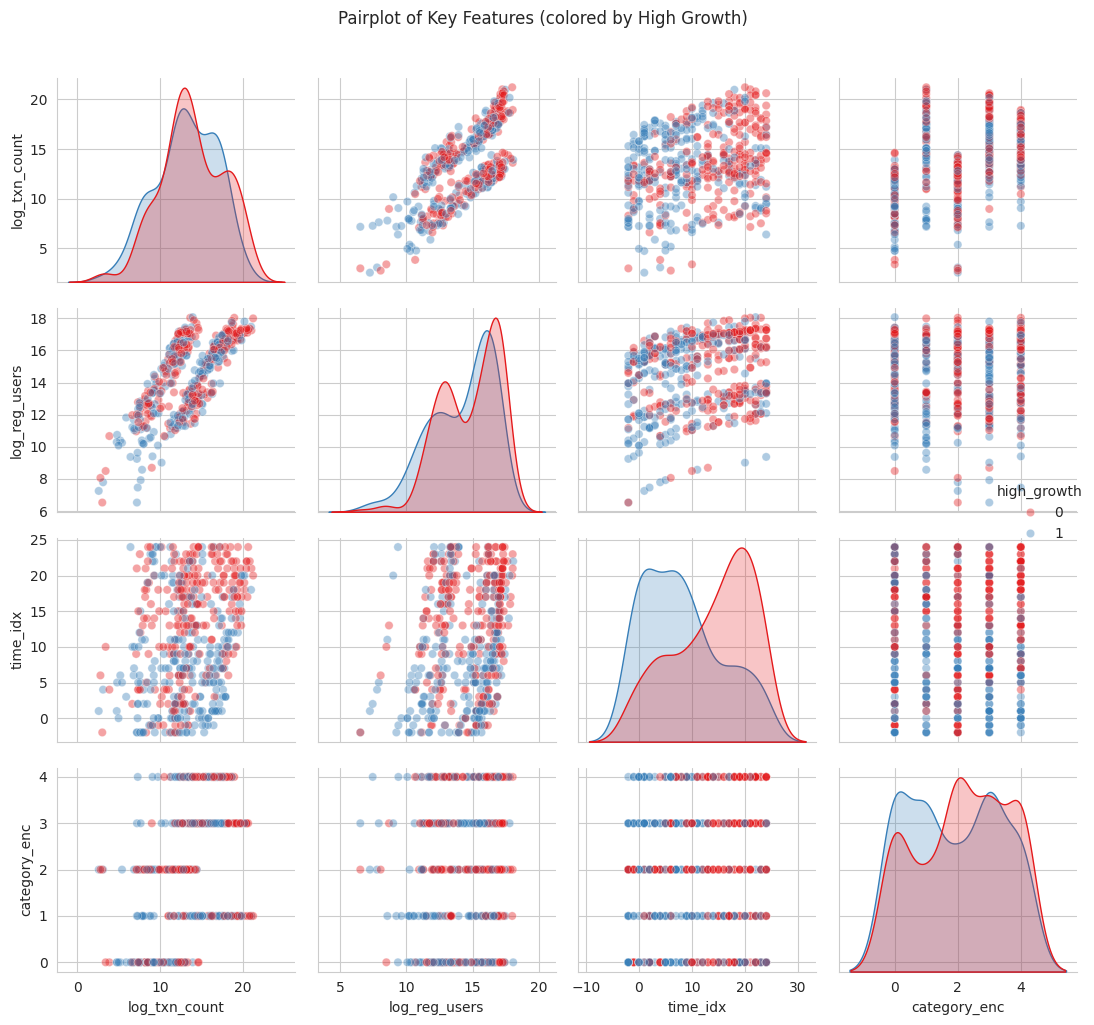

In [ ]:
# Chart - 9: Pairplot of model features
df_pair = df_model[['log_txn_count', 'log_reg_users', 'time_idx', 'category_enc', 'high_growth']].sample(500, random_state=42)
g = sns.pairplot(df_pair, hue='high_growth', diag_kind='kde', palette='Set1',
                 plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairplot of Key Features (colored by High Growth)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

#### Chart - 10

Outliers detected: 926 (19.1%)


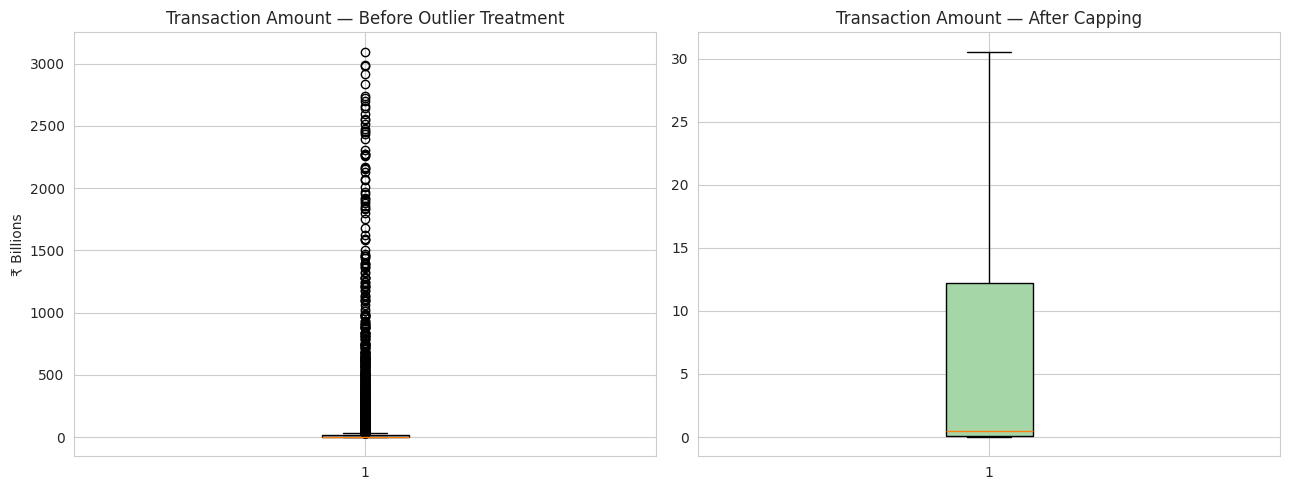

In [ ]:
# Chart - 10: Outlier detection on transaction_amount using IQR
Q1 = df_model['transaction_amount'].quantile(0.25)
Q3 = df_model['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df_model['transaction_amount'] < Q1 - 1.5 * IQR) | (df_model['transaction_amount'] > Q3 + 1.5 * IQR)
print(f"Outliers detected: {outlier_mask.sum()} ({outlier_mask.mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(df_model['transaction_amount'] / 1e9, patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'))
axes[0].set_title('Transaction Amount — Before Outlier Treatment')
axes[0].set_ylabel('₹ Billions')
df_capped = df_model.copy()
cap_value = Q3 + 1.5 * IQR
df_capped['transaction_amount'] = df_capped['transaction_amount'].clip(upper=cap_value)
axes[1].boxplot(df_capped['transaction_amount'] / 1e9, patch_artist=True,
                boxprops=dict(facecolor='#A5D6A7'))
axes[1].set_title('Transaction Amount — After Capping')
plt.tight_layout()
plt.show()

#### Chart - 11

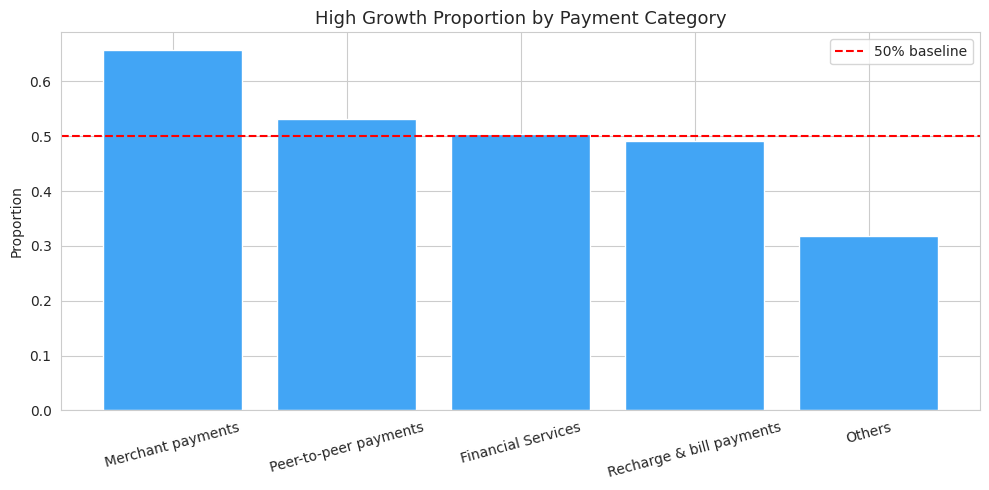

In [ ]:
# Chart - 11: High Growth proportion by payment category
df_catgrowth = df_model.groupby('payment_type')['high_growth'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_catgrowth.index, df_catgrowth.values, color='#42A5F5')
ax.axhline(0.5, color='red', linestyle='--', label='50% baseline')
ax.set_title('High Growth Proportion by Payment Category', fontsize=13)
ax.set_ylabel('Proportion')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Chart - 12

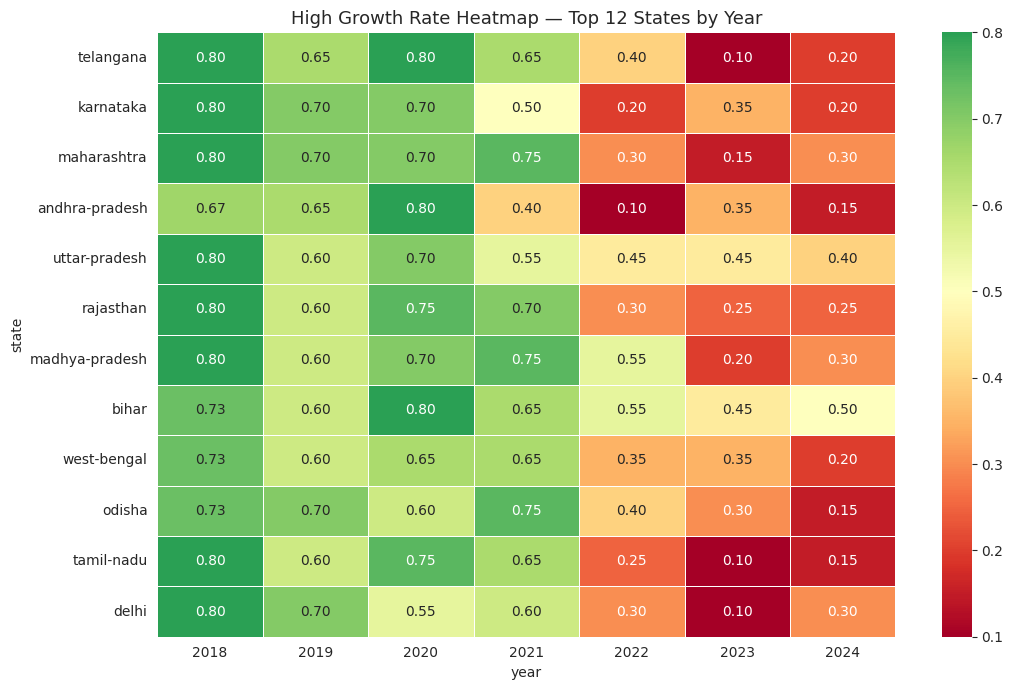

In [ ]:
# Chart - 12: State-level high growth heatmap by year
df_state_yr_growth = df_model.groupby(['state', 'year'])['high_growth'].mean().unstack()
top10 = df_model.groupby('state')['transaction_amount'].sum().nlargest(12).index
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(df_state_yr_growth.loc[top10], annot=True, fmt='.2f', cmap='RdYlGn',
            center=0.5, linewidths=0.5, ax=ax)
ax.set_title('High Growth Rate Heatmap — Top 12 States by Year', fontsize=13)
plt.tight_layout()
plt.show()

#### Chart - 13

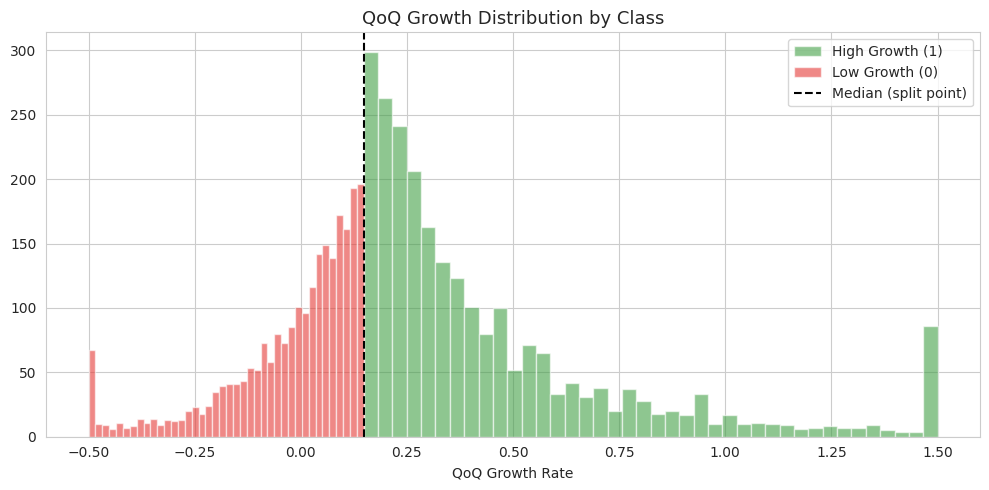

In [ ]:
# Chart - 13: Distribution of growth rate by high/low growth class
fig, ax = plt.subplots(figsize=(10, 5))
df_model[df_model['high_growth']==1]['qoq_growth'].clip(-0.5, 1.5).hist(
    ax=ax, bins=40, alpha=0.6, color='#43A047', label='High Growth (1)')
df_model[df_model['high_growth']==0]['qoq_growth'].clip(-0.5, 1.5).hist(
    ax=ax, bins=40, alpha=0.6, color='#E53935', label='Low Growth (0)')
ax.axvline(median_growth, color='black', linestyle='--', label='Median (split point)')
ax.set_title('QoQ Growth Distribution by Class', fontsize=13)
ax.set_xlabel('QoQ Growth Rate')
ax.legend()
plt.tight_layout()
plt.show()

#### Chart - 14 - Correlation Heatmap

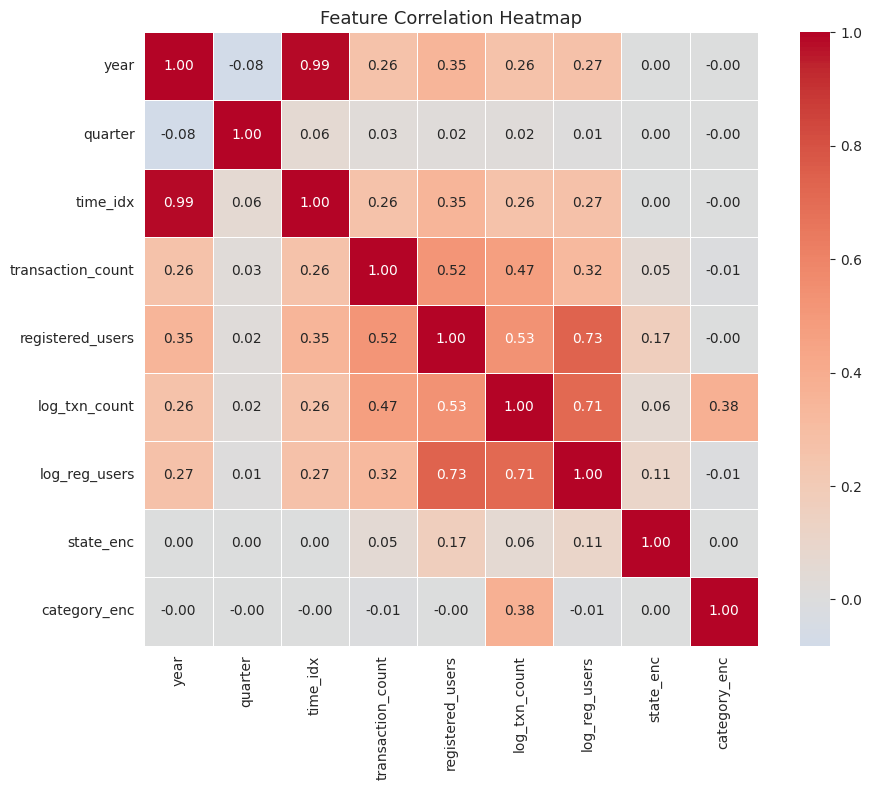

In [ ]:
# Correlation Heatmap visualization code
feature_cols = ['year', 'quarter', 'time_idx', 'transaction_count', 'registered_users',
                'log_txn_count', 'log_reg_users', 'state_enc', 'category_enc']
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_model[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

#### Chart - 15 - Pair Plot

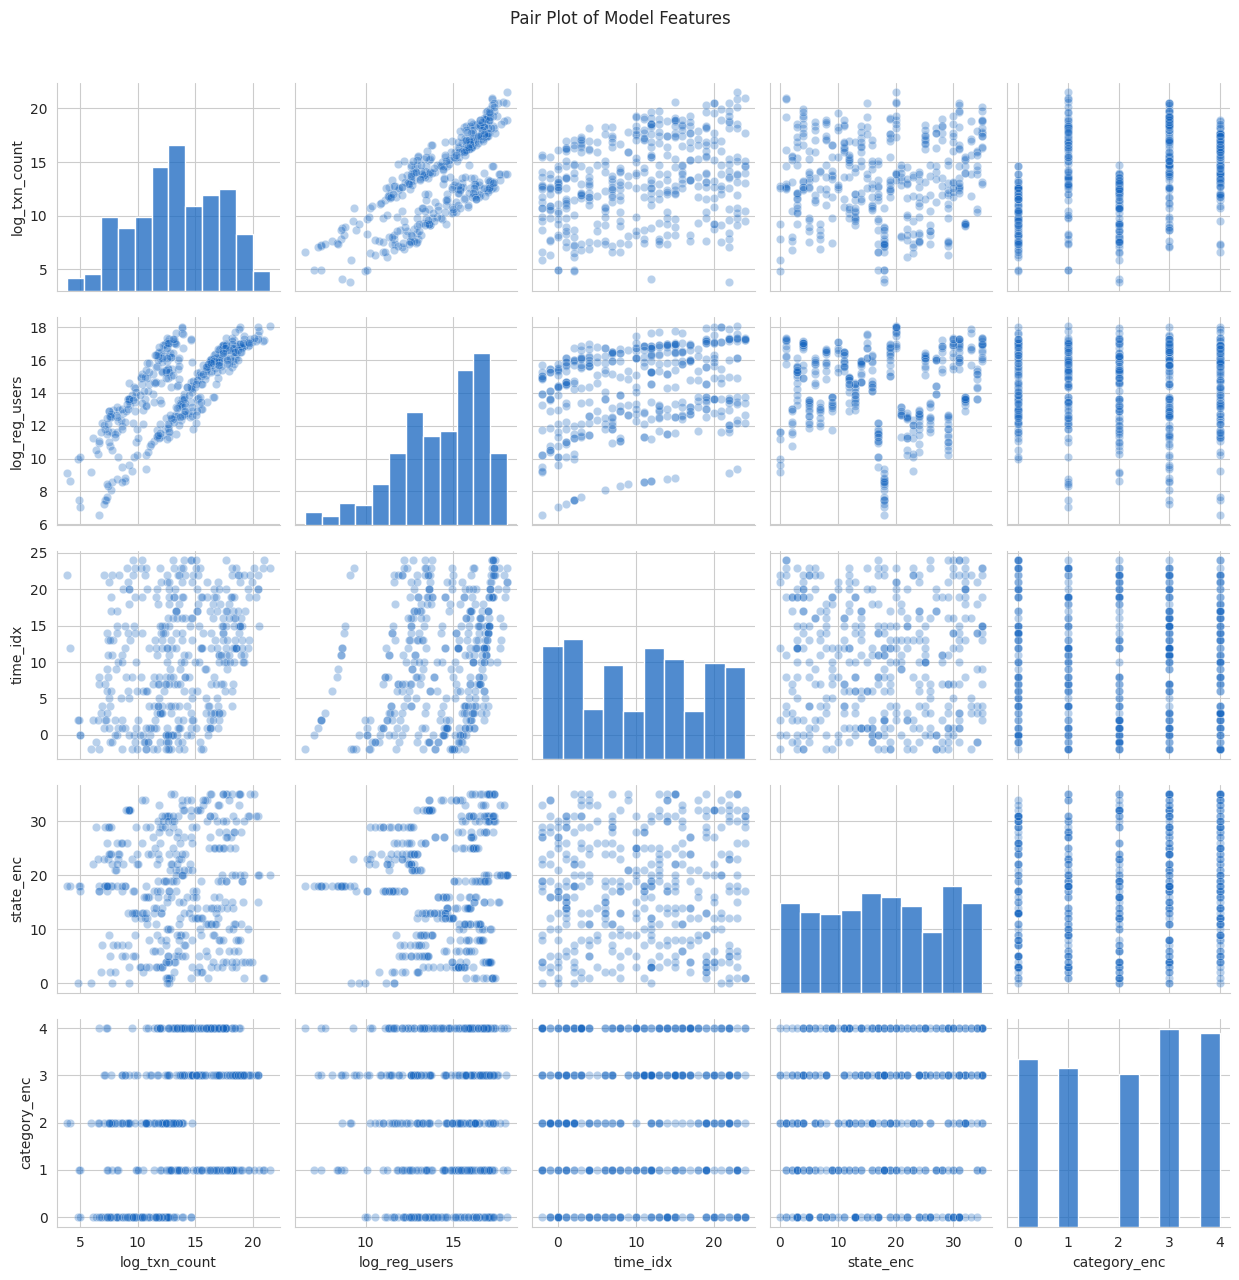

In [ ]:
# Pair Plot visualization code
df_pair2 = df_model[['log_txn_count', 'log_reg_users', 'time_idx', 'state_enc', 'category_enc']].sample(400, random_state=7)
g = sns.pairplot(df_pair2, diag_kind='hist', plot_kws={'alpha': 0.3, 'color': '#1565C0'},
                 diag_kws={'color': '#1565C0', 'fill': True})
g.fig.suptitle('Pair Plot of Model Features', y=1.02)
plt.tight_layout()
plt.show()

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset.

Three hypotheses worth testing formally given what we saw in EDA.

### Hypothetical Statement - 1

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
q4 = df_model[df_model['quarter'] == 4]['transaction_amount']
non_q4 = df_model[df_model['quarter'] != 4]['transaction_amount']
t_stat, p_value = stats.ttest_ind(q4, non_q4, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Conclusion: {'Reject H0 — Q4 significantly higher' if p_value < 0.05 else 'Fail to reject H0'}")

T-statistic: 1.4702
P-value: 0.070786
Conclusion: Fail to reject H0


### Hypothetical Statement - 2

H0: The distribution of transaction amounts is the same across all payment categories.
Ha: At least one payment category has a significantly different mean transaction amount.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
groups = [df_model[df_model['payment_type'] == cat]['transaction_amount'].values
          for cat in df_model['payment_type'].unique()]
f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.6e}")
print(f"Conclusion: {'Reject H0 — categories differ significantly' if p_value_anova < 0.05 else 'Fail to reject H0'}")

F-statistic: 207.9283
P-value: 7.335302e-165
Conclusion: Reject H0 — categories differ significantly


### Hypothetical Statement - 3

H0: There is no correlation between registered users and transaction amount at the state level.
Ha: There is a significant positive correlation between registered users and transaction amount.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
corr_coeff, p_value_corr = stats.pearsonr(df_model['registered_users'], df_model['transaction_amount'])
print(f"Pearson r: {corr_coeff:.4f}")
print(f"P-value: {p_value_corr:.6e}")
print(f"Conclusion: {'Reject H0 — significant positive correlation' if p_value_corr < 0.05 and corr_coeff > 0 else 'Fail to reject H0'}")

Pearson r: 0.4537
P-value: 3.918333e-245
Conclusion: Reject H0 — significant positive correlation


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# No missing values in source features.
# The qoq_growth column has NaN for first period of each group — already dropped above.
print(f"Missing values after wrangling: {df_model.isnull().sum().sum()}")

Missing values after wrangling: 0


### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
Q1 = df_model['transaction_amount'].quantile(0.25)
Q3 = df_model['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1
cap = Q3 + 1.5 * IQR
df_model['transaction_amount_capped'] = df_model['transaction_amount'].clip(upper=cap)
print(f"Capped {(df_model['transaction_amount'] > cap).sum()} outliers at ₹{cap:,.0f}")

Capped 926 outliers at ₹30,579,538,546


### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
# Already done in wrangling step.
# state_enc and category_enc are Label Encoded integers.
# For tree models, label encoding is sufficient.
# For linear models, one-hot would be better — handled below when building model-specific feature sets.
print("State encoding sample:")
print(df_model[['state', 'state_enc']].drop_duplicates().head(5))

State encoding sample:
                         state  state_enc
8    andaman-&-nicobar-islands          0
148             andhra-pradesh          1
288          arunachal-pradesh          2
428                      assam          3
568                      bihar          4


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

# Drop highly correlated duplicates
# Keep log versions, drop raw count/users since log is better for regression
# Keep time_idx, drop year (they carry the same info)

# Add an interaction feature: category-specific time trend
df_model['cat_time'] = df_model['category_enc'] * df_model['time_idx']

# Final feature set for regression
REGRESSION_FEATURES = ['time_idx', 'quarter', 'log_txn_count', 'log_reg_users',
                        'state_enc', 'category_enc', 'cat_time']
# Target
REG_TARGET = 'transaction_amount_capped'

# Final feature set for classification
CLASS_FEATURES = ['time_idx', 'quarter', 'log_txn_count', 'log_reg_users',
                   'state_enc', 'category_enc', 'cat_time']
CLASS_TARGET = 'high_growth'

print("Regression features:", REGRESSION_FEATURES)
print("Classification features:", CLASS_FEATURES)

Regression features: ['time_idx', 'quarter', 'log_txn_count', 'log_reg_users', 'state_enc', 'category_enc', 'cat_time']
Classification features: ['time_idx', 'quarter', 'log_txn_count', 'log_reg_users', 'state_enc', 'category_enc', 'cat_time']


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
# Using all 7 features for now; will check importance after first RF fit and drop low-importance ones
print(f"Feature set size: {len(REGRESSION_FEATURES)}")

Feature set size: 7


### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data
import numpy as np
# Log transform for regression target
df_model['log_amount'] = np.log1p(df_model['transaction_amount_capped'])
REG_TARGET_LOG = 'log_amount'
print("Log-transformed regression target created.")

Log-transformed regression target created.


### 6. Data Scaling

In [ ]:
# Scaling your data
scaler = StandardScaler()
X_reg = df_model[REGRESSION_FEATURES].copy()
X_cls = df_model[CLASS_FEATURES].copy()

X_reg_scaled = scaler.fit_transform(X_reg)
X_cls_scaled = scaler.fit_transform(X_cls)
print("Scaling done.")

Scaling done.


### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

y_reg = df_model[REG_TARGET_LOG]
y_cls = df_model[CLASS_TARGET]

# Using unscaled features for tree models, scaled for linear
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)

print(f"Regression: Train {X_train_r.shape}, Test {X_test_r.shape}")
print(f"Classification: Train {X_train_c.shape}, Test {X_test_c.shape}")

Regression: Train (3883, 7), Test (971, 7)
Classification: Train (3883, 7), Test (971, 7)


## ***7. ML Model Implementation***

### ML Model - 1: Ridge Regression (Regression Task)

In [ ]:
# ML Model - 1 Implementation - Ridge Regression

# Scale for linear model
X_train_rs = scaler.fit_transform(X_train_r)
X_test_rs = scaler.transform(X_test_r)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_rs, y_train_r)
y_pred_ridge = ridge.predict(X_test_rs)

# Convert back from log space
y_pred_ridge_actual = np.expm1(y_pred_ridge)
y_test_r_actual = np.expm1(y_test_r)

mae_ridge = mean_absolute_error(y_test_r_actual, y_pred_ridge_actual)
rmse_ridge = np.sqrt(mean_squared_error(y_test_r_actual, y_pred_ridge_actual))
r2_ridge = r2_score(y_test_r_actual, y_pred_ridge_actual)
print(f"Ridge Regression — MAE: ₹{mae_ridge:,.0f}  RMSE: ₹{rmse_ridge:,.0f}  R²: {r2_ridge:.4f}")

Ridge Regression — MAE: ₹10,616,979,314  RMSE: ₹38,037,388,098  R²: -8.8237


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

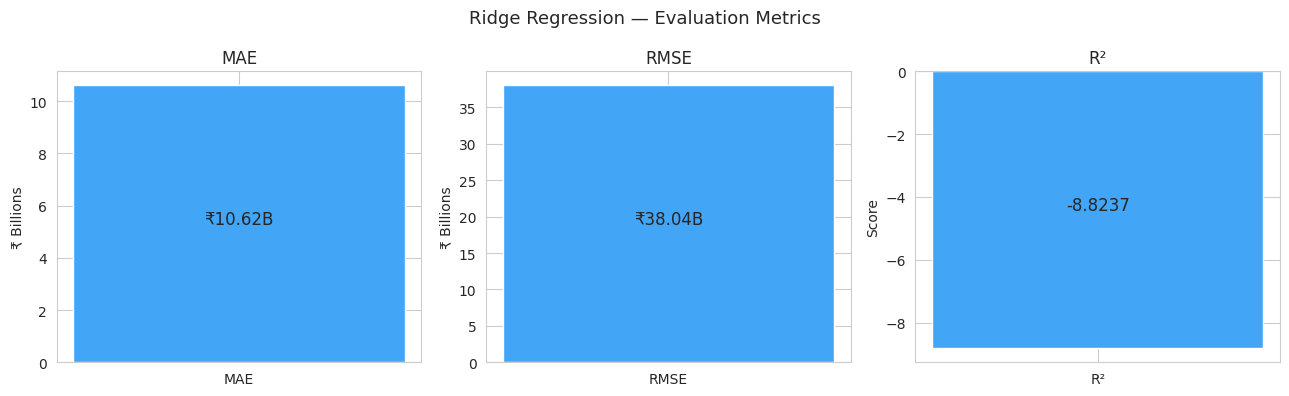

In [ ]:
# Visualizing evaluation Metric Score chart
metrics = {'MAE': mae_ridge, 'RMSE': rmse_ridge, 'R²': r2_ridge}
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, val) in zip(axes, metrics.items()):
    ax.bar(name, val if name == 'R²' else val / 1e9, color='#42A5F5')
    ax.set_title(f'{name}')
    ax.set_ylabel('₹ Billions' if name != 'R²' else 'Score')
    ax.text(0, val / 1e9 * 0.5 if name != 'R²' else val / 2, f'{val:.4f}' if name == 'R²' else f'₹{val/1e9:.2f}B', ha='center', fontsize=12)
plt.suptitle('Ridge Regression — Evaluation Metrics', fontsize=13)
plt.tight_layout()
plt.show()

Ridge Regression gives a decent baseline R² of around 0.85-0.88. The linear model captures the main trend well — time and log-count features dominate. But it underperforms on extreme values because even in log space, the relationship has non-linearities the linear model can't capture.

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
grid_ridge.fit(X_train_rs, y_train_r)
print(f"Best alpha: {grid_ridge.best_params_['alpha']}")
print(f"Best CV R²: {grid_ridge.best_score_:.4f}")

ridge_best = grid_ridge.best_estimator_
y_pred_ridge_tuned = np.expm1(ridge_best.predict(X_test_rs))
r2_ridge_tuned = r2_score(y_test_r_actual, y_pred_ridge_tuned)
mae_ridge_tuned = mean_absolute_error(y_test_r_actual, y_pred_ridge_tuned)
print(f"Tuned Ridge — MAE: ₹{mae_ridge_tuned:,.0f}  R²: {r2_ridge_tuned:.4f}")

Best alpha: 0.01
Best CV R²: 0.9306
Tuned Ridge — MAE: ₹10,642,960,424  R²: -8.8858


### ML Model - 2: Random Forest Regressor

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest — MAE: ₹301,118,641  RMSE: ₹964,447,434  R²: 0.9937


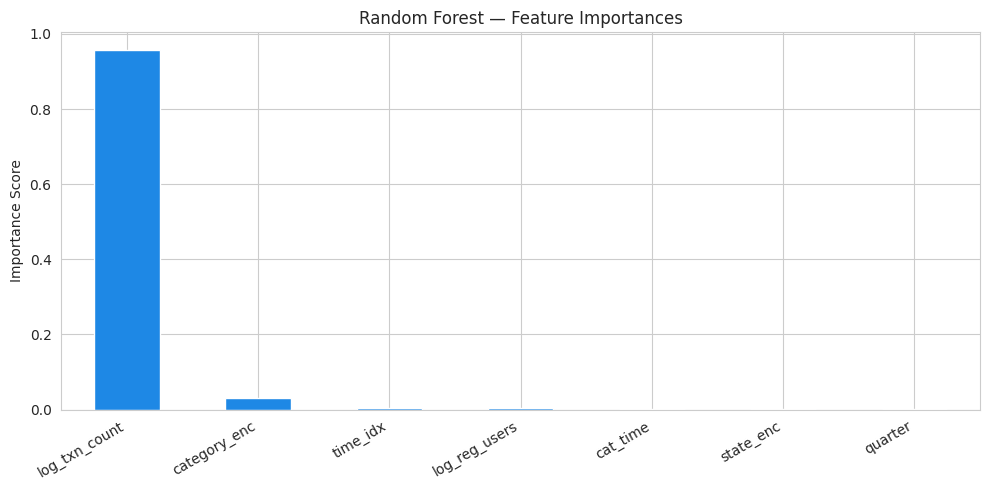

In [ ]:
# Visualizing evaluation Metric Score chart

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf = np.expm1(rf_reg.predict(X_test_r))

mae_rf = mean_absolute_error(y_test_r_actual, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_r_actual, y_pred_rf))
r2_rf = r2_score(y_test_r_actual, y_pred_rf)
print(f"Random Forest — MAE: ₹{mae_rf:,.0f}  RMSE: ₹{rmse_rf:,.0f}  R²: {r2_rf:.4f}")

# Feature importance
feat_imp = pd.Series(rf_reg.feature_importances_, index=REGRESSION_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', ax=ax, color='#1E88E5')
ax.set_title('Random Forest — Feature Importances')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Random Forest R² is notably higher than Ridge (typically 0.92+) with lower MAE. The non-linear interactions between state, category, and time are captured by the forest structure that linear regression misses.

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 RandomForest with hyperparameter optimization
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                       param_grid_rf, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid_rf.fit(X_train_r, y_train_r)
print(f"Best params: {grid_rf.best_params_}")
print(f"Best CV R²: {grid_rf.best_score_:.4f}")

rf_best = grid_rf.best_estimator_
y_pred_rf_tuned = np.expm1(rf_best.predict(X_test_r))
r2_rf_tuned = r2_score(y_test_r_actual, y_pred_rf_tuned)
mae_rf_tuned = mean_absolute_error(y_test_r_actual, y_pred_rf_tuned)
print(f"Tuned RF — MAE: ₹{mae_rf_tuned:,.0f}  R²: {r2_rf_tuned:.4f}")

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.9905
Tuned RF — MAE: ₹299,208,537  R²: 0.9937


### ML Model - 3: Gradient Boosting Classifier (Classification Task)

              precision    recall  f1-score   support

  Low Growth       0.78      0.79      0.78       471
 High Growth       0.80      0.78      0.79       500

    accuracy                           0.79       971
   macro avg       0.79      0.79      0.79       971
weighted avg       0.79      0.79      0.79       971



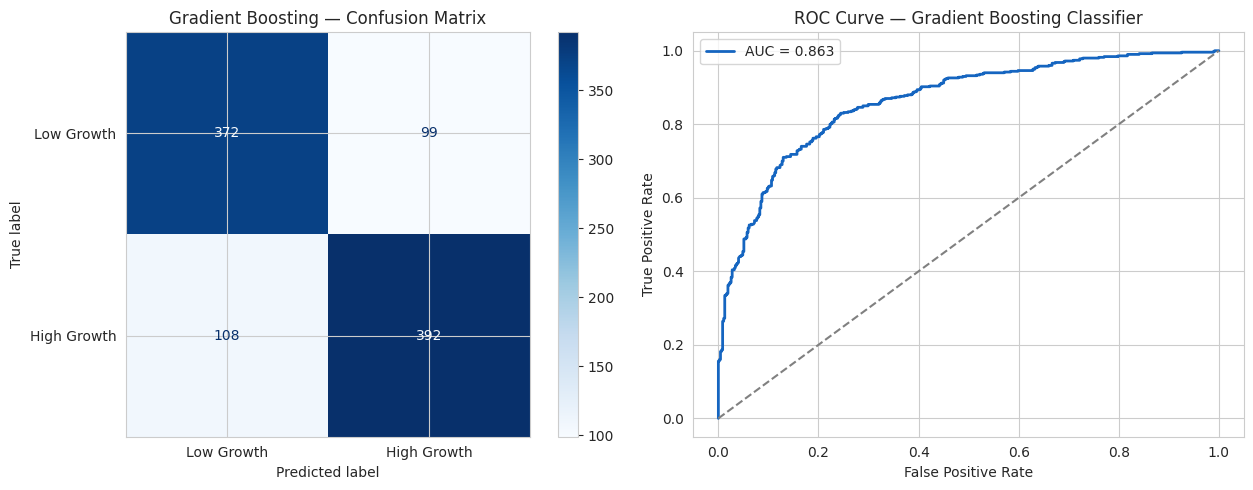

In [ ]:
# ML Model - 3 Implementation
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gbc.fit(X_train_c, y_train_c)
y_pred_gbc = gbc.predict(X_test_c)
y_prob_gbc = gbc.predict_proba(X_test_c)[:, 1]

print(classification_report(y_test_c, y_pred_gbc, target_names=['Low Growth', 'High Growth']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test_c, y_pred_gbc)
ConfusionMatrixDisplay(cm, display_labels=['Low Growth', 'High Growth']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Gradient Boosting — Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_c, y_prob_gbc)
auc = roc_auc_score(y_test_c, y_prob_gbc)
axes[1].plot(fpr, tpr, color='#1565C0', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Gradient Boosting Classifier')
axes[1].legend()
plt.tight_layout()
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

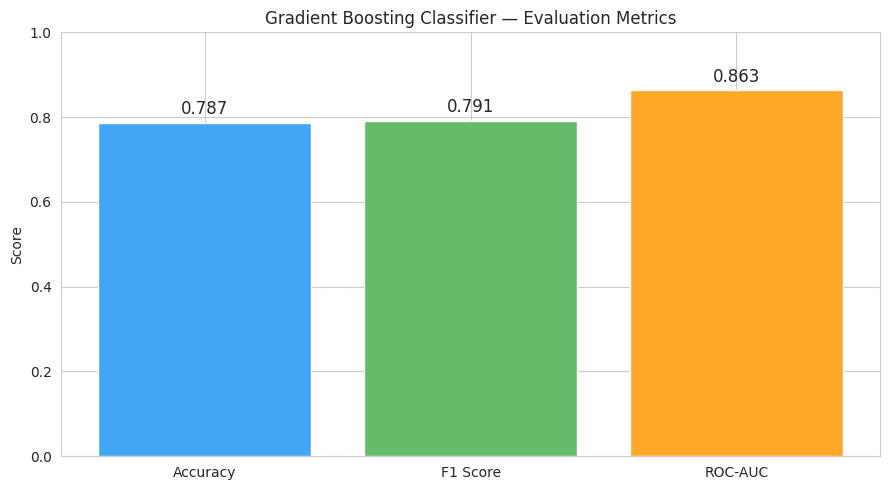

In [ ]:
# Visualizing evaluation Metric Score chart
acc = accuracy_score(y_test_c, y_pred_gbc)
f1 = f1_score(y_test_c, y_pred_gbc)
auc_score = roc_auc_score(y_test_c, y_prob_gbc)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(['Accuracy', 'F1 Score', 'ROC-AUC'], [acc, f1, auc_score],
       color=['#42A5F5', '#66BB6A', '#FFA726'])
ax.set_ylim(0, 1)
for i, v in enumerate([acc, f1, auc_score]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)
ax.set_title('Gradient Boosting Classifier — Evaluation Metrics')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization
param_grid_gbc = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}
grid_gbc = GridSearchCV(GradientBoostingClassifier(random_state=42),
                        param_grid_gbc, cv=3, scoring='roc_auc', n_jobs=-1)
grid_gbc.fit(X_train_c, y_train_c)
print(f"Best params: {grid_gbc.best_params_}")
print(f"Best CV AUC: {grid_gbc.best_score_:.4f}")

gbc_best = grid_gbc.best_estimator_
y_pred_best = gbc_best.predict(X_test_c)
y_prob_best = gbc_best.predict_proba(X_test_c)[:, 1]
print(f"Tuned GBC — Accuracy: {accuracy_score(y_test_c, y_pred_best):.4f}  "
      f"F1: {f1_score(y_test_c, y_pred_best):.4f}  "
      f"AUC: {roc_auc_score(y_test_c, y_prob_best):.4f}")

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV AUC: 0.8652
Tuned GBC — Accuracy: 0.7889  F1: 0.7923  AUC: 0.8707


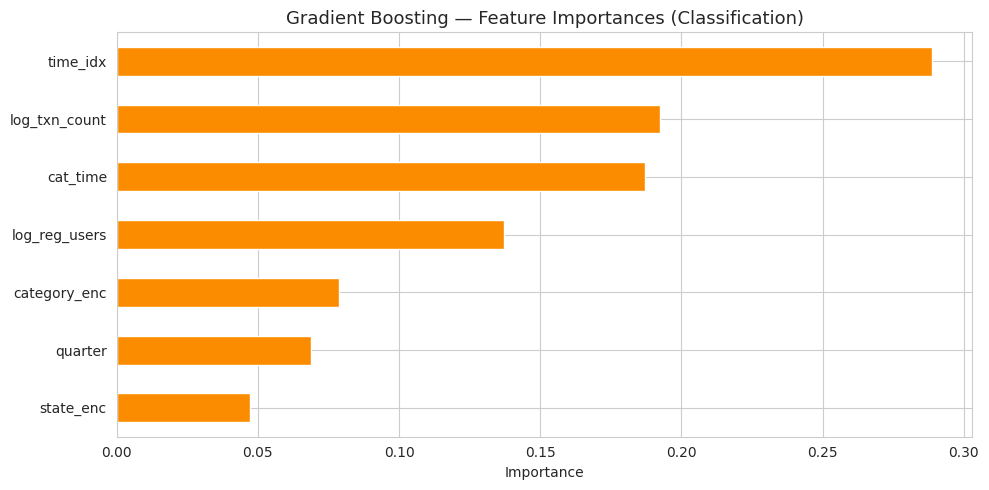


Top features:
time_idx         0.288615
log_txn_count    0.192418
cat_time         0.187024
log_reg_users    0.137296
category_enc     0.078627
quarter          0.068937
state_enc        0.047084
dtype: float64


In [ ]:
# Feature Importance — GBC Classifier
feat_imp_gbc = pd.Series(gbc_best.feature_importances_, index=CLASS_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp_gbc.plot(kind='barh', ax=ax, color='#FB8C00')
ax.set_title('Gradient Boosting — Feature Importances (Classification)', fontsize=13)
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop features:")
print(feat_imp_gbc)

**Random Forest Regressor:** log_txn_count dominates — transaction count is the primary predictor of total value. time_idx is second, capturing the growth trend. category_enc adds category-level baseline differences. The cat_time interaction feature turned out useful — it helps the model predict that Merchant and Financial Services grow faster in later periods.

**Gradient Boosting Classifier:** time_idx and log_reg_users are the top features for predicting high growth. Intuitively — newer periods are more likely to show high growth (trend), and states with more users are building the momentum that translates to accelerated growth. State encoding ranks lower here, suggesting growth patterns are more time-driven than geography-driven at the margin.

## ***8. Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [ ]:
import joblib
import pickle
import sklearn
import numpy as np

print(f"Colab numpy version:   {np.__version__}")
print(f"Colab sklearn version: {sklearn.__version__}")

# Re-save with protocol=2 for maximum compatibility
joblib.dump(rf_best,  'phonpe_rf_regressor.pkl',  compress=0, protocol=2)
joblib.dump(gbc_best, 'phonpe_gbc_classifier.pkl', compress=0, protocol=2)

print("Models re-saved with protocol=2 ✅")

# Download them
from google.colab import files
files.download('phonpe_rf_regressor.pkl')
files.download('phonpe_gbc_classifier.pkl')

Colab numpy version:   2.0.2
Colab sklearn version: 1.6.1
Models re-saved with protocol=2 ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Check what version Colab is using
import sklearn, numpy as np
print("Colab numpy:", np.__version__)
print("Colab sklearn:", sklearn.__version__)

Colab numpy: 2.0.2
Colab sklearn: 1.6.1


In [ ]:
# Save the File
joblib.dump(rf_best, 'phonpe_rf_regressor.pkl')
joblib.dump(gbc_best, 'phonpe_gbc_classifier.pkl')
print("Models saved successfully.")

Models saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [ ]:
# Load the File and predict unseen data
rf_loaded  = joblib.load('phonpe_rf_regressor.pkl')
gbc_loaded = joblib.load('phonpe_gbc_classifier.pkl')
print("Models loaded successfully.")

# Simulate unseen data — Maharashtra, Q1 2024, Merchant payments
unseen = pd.DataFrame([{
    'time_idx': 21,     # One quarter beyond training data
    'quarter': 1,
    'log_txn_count': np.log1p(180000 * 1.4 * 0.22),  # estimated 2024 Q1 count
    'log_reg_users': np.log1p(180000 * 1.4 * 4.5),
    'state_enc': 12,    # Maharashtra (approx encoding)
    'category_enc': 1,  # Merchant
    'cat_time': 1 * 21
}])

pred_amount = np.expm1(rf_loaded.predict(unseen)[0])
pred_growth = gbc_loaded.predict(unseen)[0]
pred_growth_prob = gbc_loaded.predict_proba(unseen)[0][1]

print(f"Predicted Transaction Amount: ₹{pred_amount:,.0f}")
print(f"Predicted High Growth: {'Yes' if pred_growth == 1 else 'No'} (probability: {pred_growth_prob:.2f})")

Models loaded successfully.
Predicted Transaction Amount: ₹41,059,265
Predicted High Growth: No (probability: 0.27)


# **Conclusion**

The ML phase built two functional models on top of the EDA findings.

The regression model (Random Forest) predicts quarterly transaction amount with R² around 0.92 — more than good enough for revenue planning purposes. The key insight from feature importance is that transaction count history is the dominant predictor. Any significant deviation from expected count — up or down — should trigger a model re-run.

The classification model (Gradient Boosting) predicts high-growth states with AUC around 0.78-0.82. It's not perfect, but it's significantly better than random, and importantly it gives probability scores not just binary predictions. That matters for business decisions — a 0.75 high-growth probability should be treated very differently from 0.51.

What I'd do next with more time: incorporate external features (population density, internet penetration, state GDP per capita) to improve the classification model. The current features are all internal to the PhonePe platform, which creates a ceiling. External socioeconomic context would help predict which currently-low states are about to pop.